In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/online_retail.csv', encoding='unicode_escape')
print("Kích thước ban đầu:", df.shape)

Kích thước ban đầu: (541909, 8)


In [18]:
#Lấy ngẫu nhiên 10% dl để dễ quản lý
df_sampled = df.sample(frac=0.1, random_state=42)
print("Kích thước sau khi lấy mẫu:", df_sampled.shape)

Kích thước sau khi lấy mẫu: (54191, 8)


In [19]:
#Làm sạch dữ liệu
#Xóa dòng null
df_clean = df_sampled.dropna()

#Lọc bỏ hàng trả lại (Quantity < 0) và hàng miễn phí (InitPrice == 0)
df_clean = df_clean[(df_clean['Quantity']> 0) & (df_clean['UnitPrice']> 0)]

print("Kích thước sau khi làm sạch:", df_clean.shape)

Kích thước sau khi làm sạch: (39635, 8)


In [20]:
#Xử lý thời gian và tính doanh thu
#Chuyển invoiceDate sang datetime
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

#Tạo cột Revenue (Doanh thu = Số lượng x Đơn giá)
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['UnitPrice']
df_clean.head()

,ï»¿InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
209268,555200,71459,HANGING JAM JAR T-LIGHT HOLDER,24,2011-06-01 12:05:00,0.85,17315.0,United Kingdom,20.40
207108,554974,21128,GOLD FISHING GNOME,4,2011-05-27 17:14:00,6.95,14031.0,United Kingdom,27.80
167085,550972,21086,SET/6 RED SPOTTY PAPER CUPS,4,2011-04-21 17:05:00,0.65,14031.0,United Kingdom,2.60
471836,576652,22812,PACK 3 BOXES CHRISTMAS PANETTONE,3,2011-11-16 10:39:00,1.95,17198.0,United Kingdom,5.85
115865,546157,22180,RETROSPOT LAMP,2,2011-03-10 08:40:00,9.95,13502.0,United Kingdom,19.90


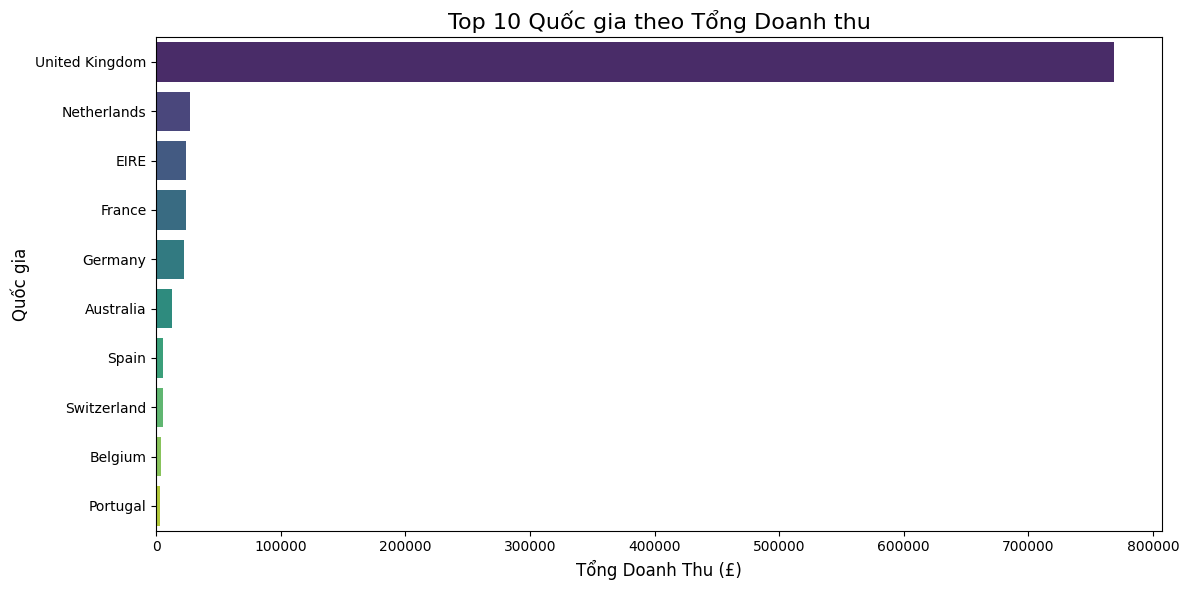

In [21]:
#Phân tích và vẽ biểu đồ
#Tìm top 10 quốc gia theo tổng doanh thu
top_10_countries = df_clean.groupby('Country')['Revenue'].sum().nlargest(10)

#Vẽ biểu đồ
plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_countries.values, y=top_10_countries.index, hue=top_10_countries.index, legend=False, palette='viridis')

plt.title('Top 10 Quốc gia theo Tổng Doanh thu', fontsize=16)
plt.xlabel('Tổng Doanh Thu (£)', fontsize=12)
plt.ylabel('Quốc gia', fontsize=12)
plt.tight_layout()
plt.show()